In [26]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import os

from pathlib import Path
import warnings
from firthlogist import FirthLogisticRegression
from scipy.optimize import curve_fit
from scipy import stats
from sklearn.utils.validation import check_X_y

# Opening cleaned PAROS dataset

In [27]:
CURRENT_DIRECTORY = Path.cwd().resolve()

# Find project root that contains datasets
PROJECT_ROOT = next(
    p for p in [CURRENT_DIRECTORY, *CURRENT_DIRECTORY.parents]
    if (p / "datasets").exists()
)

CLEANED_DATASET_PATH = PROJECT_ROOT / "datasets" / "PAROS_Dataset_Cleaned.csv"

if not CLEANED_DATASET_PATH.exists():
    raise FileNotFoundError(f"Cleaned dataset not found: {CLEANED_DATASET_PATH}")

df = pd.read_csv(CLEANED_DATASET_PATH)
print(f"Loaded cleaned PAROS dataset: {df.shape}")
display(df.head(3))


Loaded cleaned PAROS dataset: (2039, 71)


,Patient brought in by,Date of Incident,Location of incident,Location Unknown,Location Type,Location Type Other,Age,Age Modifier,Gender,Race,...,Outcome of patient,Patient status,Date of Discharge or Death,Patient neurological status - Cerebral,Patient neurological status - Overall,Patient neurological status - Unknown,Year,Call_Time,Shock_Time,Time_to_Defib
0,Ems,2014-01-01,238889.0,NaN,Transport Center,Dhoby Ghaut Mrt Level B1,59,Years,Male,Chinese,...,Died In Ed,NaN,NaN,5.0,NaN,NaN,2014,2026-04-06 22:28:12,2026-04-06 22:39:17,11.083333
1,Ems,2014-01-05,272018.0,NaN,Public/Commercial Building,Level 2,66,Years,Male,Chinese,...,Died In Ed,NaN,NaN,5.0,NaN,NaN,2014,2026-04-06 15:00:42,2026-04-06 15:16:49,16.116667
2,Ems,2014-01-07,760105.0,NaN,Street/Highway,Level 1,80,Years,Male,Indian,...,Admitted,Remains In Hospital At 30Th Day Post Arrest,NaN,4.0,4.0,NaN,2014,2026-04-06 12:05:46,2026-04-06 12:14:08,8.366667


# Standardize Reporting

In [28]:
import pandas as pd
import numpy as np

def report_results(model_output, model_name="Model"):
    """
    Standardizes the reporting style for all versions.
    Prevents length-mismatch errors by building segments before joining.
    """
    print(f"\n{'='*20} {model_name} Results {'='*20}")
    
    # ---------------------------------------------------------
    # PATH A: Firthlogist Model (V3 & V4)
    # ---------------------------------------------------------
    if "firthlogist" in str(type(model_output)):
        # 1. Extract feature names and data
        features = list(getattr(model_output, 'feature_names_in_', []))
        if not features:
            features = [f'x{i+1}' for i in range(len(model_output.coef_))]
            
        # 2. Build feature table
        df_feats = pd.DataFrame(index=features)
        df_feats['Odds Ratio'] = np.exp(model_output.coef_)
        df_feats['Lower 95% CI'] = np.exp(model_output.ci_[:len(features), 0])
        df_feats['Upper 95% CI'] = np.exp(model_output.ci_[:len(features), 1])
        df_feats['p-value'] = model_output.pvals_[:len(features)]
        
        # 3. Build Intercept row separately
        # We use getattr with defaults to handle inconsistent naming in the library
        int_pval = getattr(model_output, 'intercept_pval_', getattr(model_output, 'intercept_pvals_', np.nan))
        # Handle cases where intercept_pval_ might be an array
        if isinstance(int_pval, (np.ndarray, list)): int_pval = int_pval[0]
            
        # Get Intercept CIs
        ci_int = getattr(model_output, 'ci_intercept_', [np.nan, np.nan])
        if hasattr(ci_int, 'ndim') and ci_int.ndim > 1: ci_int = ci_int.flatten()
        
        df_int = pd.DataFrame({
            'Odds Ratio': [np.exp(model_output.intercept_)],
            'Lower 95% CI': [np.exp(ci_int[0])],
            'Upper 95% CI': [np.exp(ci_int[1])],
            'p-value': [int_pval]
        }, index=['Intercept'])
        
        return pd.concat([df_feats, df_int])

    # ---------------------------------------------------------
    # PATH B: Statsmodels Model (V1 & V2)
    # ---------------------------------------------------------
    elif hasattr(model_output, 'summary2'):
        summary = model_output.summary2().tables[1].copy()
        summary.loc[:, 'OR'] = np.exp(summary['Coef.'])
        summary.loc[:, 'Lower_95_CI'] = np.exp(summary['Coef.'] - 1.96 * summary['Std.Err.'])
        summary.loc[:, 'Upper_95_CI'] = np.exp(summary['Coef.'] + 1.96 * summary['Std.Err.'])
        
        final_table = summary[['OR', 'Lower_95_CI', 'Upper_95_CI', 'P>|z|']]
        final_table.columns = ['Odds Ratio', 'Lower 95% CI', 'Upper 95% CI', 'p-value']
        return final_table
        
    else:
        raise ValueError("Unrecognized model object.")

# Define Binary Outcome (Survival to 30 Days)


In [29]:
outcome_cols = ['Outcome of patient', 'Patient status', 'Final status at scene']
df.loc[:, 'Outcome_String'] = df[outcome_cols].astype(str).agg(' '.join, axis=1)
survival_regex = r'Discharged Alive|Remains in hospital at 30th day'
df.loc[:, 'Survival_Binary'] = df['Outcome_String'].str.contains(survival_regex, case=False, regex=True).astype(int)

# Define Primary Predictor (Bystander AED applied)
- We map any variation of 'Yes' or '1' to 1, and everything else to 0

In [30]:
aed_col = 'Bystander AED applied'
df.loc[:, 'AED_Applied_Binary'] = df[aed_col].astype(str).str.contains('Yes|Applied|1', case=False, na=False).astype(int)

# Cleaned DataFrame

In [31]:
model_vars = ['Survival_Binary', 'AED_Applied_Binary', 'Time_to_Defib']
df_clean = df.dropna(subset=model_vars).copy()

# Create a new dataframe, copy and prepare for model estimation


In [32]:
v3_df = df_clean.copy()

# Sort values to ensure smooth line plotting later
v3_df = v3_df.sort_values('Time_to_Defib')

X = v3_df['Time_to_Defib'].values
y_true = v3_df['Survival_Binary'].values

# Change Point Analysis

In [ ]:
print("--- V3: PIECEWISE FIRTH LOGISTIC BREAKPOINT SEARCH ---")
print("Running profile likelihood search for Tau (1.0 to 15.0 mins)...")

best_tau = None
best_aic = np.inf
profile_results = []

# Grid search for Tau
tau_grid = np.arange(1.0, 15.1, 0.1)

for tau in tau_grid:
    # 1. Construct Piecewise Features for this Tau
    t_before = np.clip(X, a_min=None, a_max=tau)
    t_after = np.clip(X - tau, a_min=0, a_max=None)
    
    X_piecewise = pd.DataFrame({
        'Time_Before': t_before,
        'Time_After': t_after
    })
    
    # 2. Fit the Firth model
    model = FirthLogisticRegression(max_iter=500)
    try:
        model.fit(X_piecewise, y_true)
        
        # 3. Extract coefficients and calculate Likelihood/AIC
        coefs = np.array(model.coef_).flatten()
        intercept = float(model.intercept_[0]) if isinstance(model.intercept_, (list, np.ndarray)) else float(model.intercept_)
        
        # Linear predictor (log-odds)
        linear_pred = np.dot(X_piecewise, coefs) + intercept
        
        # Convert log-odds to probabilities
        p = 1 / (1 + np.exp(-linear_pred))
        p = np.clip(p, 1e-15, 1 - 1e-15)
        
        # Calculate Unpenalized Log-Likelihood
        ll = np.sum(y_true * np.log(p) + (1 - y_true) * np.log(1 - p))
        
        # k = 3 parameters (intercept, early_slope, late_slope)
        aic = 2 * 3 - 2 * ll
        
        profile_results.append({
            'tau': tau,
            'aic': aic,
            'll': ll,
            'b_early': coefs[0],
            'b_late': coefs[1],
            'intercept': intercept
        })
        
        # Track the best model
        if aic < best_aic:
            best_aic = aic
            best_tau = tau
            
    except Exception as e:
        continue

In [34]:
# 4. Extract the winning model configuration
results_df = pd.DataFrame(profile_results)
best_model = results_df.loc[results_df['aic'].idxmin()]

tau_est = best_model['tau']
beta0_est = best_model['intercept']
b_early_est = best_model['b_early']
b_late_est = best_model['b_late']

# Calculate 95% CI using Chi-Squared Likelihood Ratio Test for profile likelihood
max_ll = best_model['ll']
# Threshold for 95% CI with 1 df is 3.84, so anything within 1.92 LL units is in the CI
ci_threshold = max_ll - 1.92 
ci_taus = results_df.loc[results_df['ll'] >= ci_threshold, 'tau']
tau_ci_low = ci_taus.min()
tau_ci_high = ci_taus.max()

print(f"\nOptimal Breakpoint (Tau): {tau_est:.2f} minutes")
print(f"95% CI for Breakpoint:    [{tau_ci_low:.2f}, {tau_ci_high:.2f}]")
print(f"Intercept (beta0):        {beta0_est:.4f}")
print(f"Early Regime Decay:       {b_early_est:.4f}")
print(f"Late Regime Decay:        {b_late_est:.4f}")
print(f"Model AIC:                {best_model['aic']:.2f}")


Optimal Breakpoint (Tau): 6.90 minutes
95% CI for Breakpoint:    [1.00, 15.00]
Intercept (beta0):        -1.1945
Early Regime Decay:       0.0553
Late Regime Decay:        -0.1339
Model AIC:                1829.82


# Plot

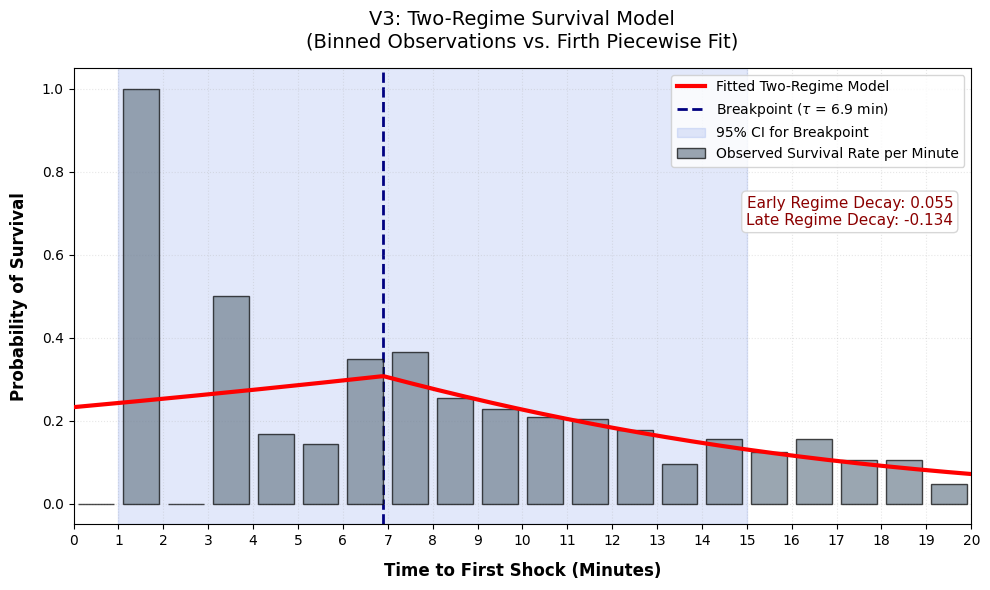

In [35]:
plt.figure(figsize=(10, 6))

# ==========================================
# 1. PLOT REAL DATA AS BINNED PROBABILITIES
# ==========================================
# Group data into 1-minute intervals
bins = np.arange(0, 31, 1)
v3_df["Time_Bin"] = pd.cut(v3_df["Time_to_Defib"], bins=bins, right=False)

binned_stats = (
    v3_df.groupby("Time_Bin", observed=False)["Survival_Binary"]
    .agg(["mean", "count"])
    .reset_index()
)

# Midpoint of each 1-minute bin
binned_stats["Bin_Mid"] = binned_stats["Time_Bin"].apply(lambda x: x.mid).astype(float)

# Remove empty bins
binned_stats = binned_stats[binned_stats["count"] > 0]

# Bar plot: mean survival rate per minute
plt.bar(
    binned_stats["Bin_Mid"],
    binned_stats["mean"],
    width=0.8,
    color="slategray",
    alpha=0.7,
    edgecolor="black",
    label="Observed Survival Rate per Minute",
    zorder=2,
)

# ==========================================
# 2. PLOT THE PIECEWISE LOGISTIC CURVE
# ==========================================
X_smooth = np.linspace(0, 30, 500)
# Manually build the piecewise vars exactly as Firth logistic saw them
t_before_smooth = np.clip(X_smooth, a_min=None, a_max=tau_est)
t_after_smooth = np.clip(X_smooth - tau_est, a_min=0, a_max=None)

# Calculate probabilities using the optimal Firth coefficients
y_linear_smooth = beta0_est + (b_early_est * t_before_smooth) + (b_late_est * t_after_smooth)
y_smooth = 1 / (1 + np.exp(-y_linear_smooth))

plt.plot(X_smooth, y_smooth, color='red', linewidth=3, zorder=3, label='Fitted Two-Regime Model')

# ==========================================
# 3. MARK THE BREAKPOINT & CONFIDENCE INTERVAL
# ==========================================
plt.axvline(x=tau_est, color='navy', linestyle='--', linewidth=2, zorder=1, label=f'Breakpoint ($\\tau$ = {tau_est:.1f} min)')
plt.axvspan(tau_ci_low, tau_ci_high, color='royalblue', alpha=0.15, zorder=0, label='95% CI for Breakpoint')

# ==========================================
# 4. CLEAN ANNOTATIONS & STYLING
# ==========================================
plt.xlim(0, 20)
plt.ylim(-0.05, 1.05)
plt.xticks(np.arange(0, 21, 1)) # Force ticks to be exactly every 1 min
plt.xlabel('Time to First Shock (Minutes)', fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel('Probability of Survival', fontsize=12, fontweight='bold', labelpad=10)
plt.title('V3: Two-Regime Survival Model\n(Binned Observations vs. Firth Piecewise Fit)', fontsize=14, pad=15)

# Place legend first so we know where it is
plt.legend(loc='upper right', frameon=True, fontsize=10)

# Move the regime text box right below the legend using relative axes coordinates
props = dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='lightgray')
plt.text(0.98, 0.72, f"Early Regime Decay: {b_early_est:.3f}\nLate Regime Decay: {b_late_est:.3f}", 
         transform=plt.gca().transAxes, # Use relative axes coords (0 to 1) rather than data coords
         fontsize=11, color='darkred', ha='right', va='top', bbox=props, zorder=4)

plt.grid(True, alpha=0.3, linestyle=':')
plt.tight_layout()
# Save for your presentation
plt.savefig('V3_Clean_Breakpoint_Model.png', dpi=300)
plt.show()